## 1. Google Drive Setup and Sample Image Visualization

This section mounts Google Drive to access the dataset and then loads and displays a few sample images from the training and testing directories. This helps to quickly verify the dataset structure and content.

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Processing Train directory: /content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/train
Found classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'tucuma', 'pupunha'] in /content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/train
  - Selected 1 image from class 'pupunha'. Total selected for Train: 1
  - Selected 1 image from class 'guarana'. Total selected for Train: 2
Processing Test directory: /content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/test
Found classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma'] in /content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/test
  - Selected 1 image from class 'graviola'. Total selected for Test: 1
  - Selected 1 image from class 'acai'. Total selected for Test: 2


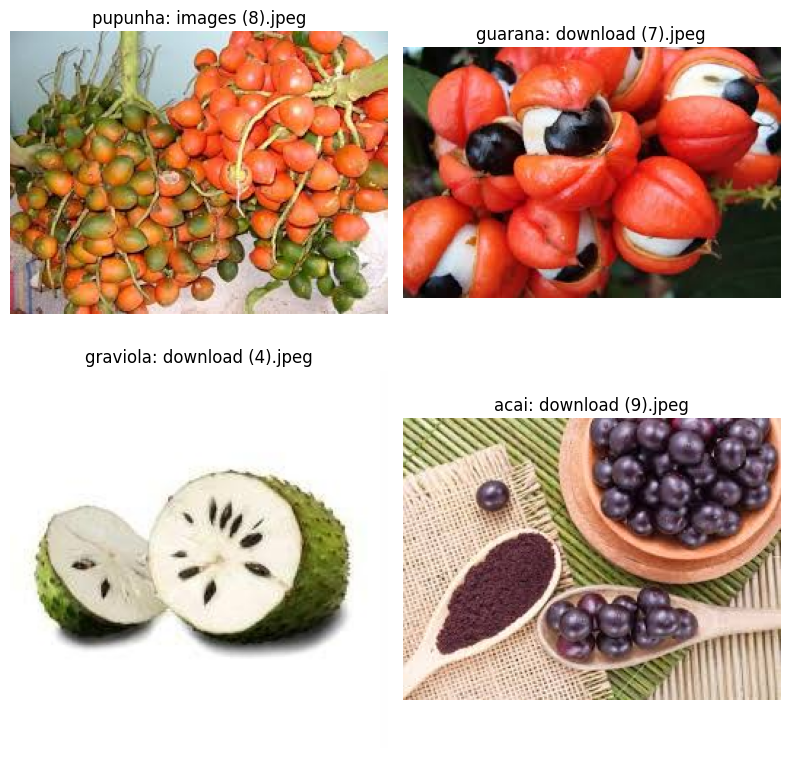

Total images found across all specified directories: 40


In [3]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# 1. Set the base directories for your dataset
train_dir = '/content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/train'
test_dir = '/content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/test'

directories_to_process = [
    (train_dir, "Train"),
    (test_dir, "Test")
]

all_selected_images = []
total_images_found = 0

for current_dataset_base_dir, dataset_type_label in directories_to_process:
    print(f"Processing {dataset_type_label} directory: {current_dataset_base_dir}")

    if not os.path.isdir(current_dataset_base_dir):
        print(f"Error: Directory not found at {current_dataset_base_dir}. Please ensure your Google Drive is mounted and the path is correct.")
        continue

    # Get class subdirectories (fruit names)
    class_names = [d for d in os.listdir(current_dataset_base_dir) if os.path.isdir(os.path.join(current_dataset_base_dir, d))]

    if not class_names:
        print(f"No class subdirectories found in {current_dataset_base_dir}.")
        # If no class subdirectories, check if images are directly in the base directory
        all_images_in_base_dir = [f for f in os.listdir(current_dataset_base_dir) if f.lower().endswith(('.jpeg', '.jpg', '.jpeg', '.gif', '.bmp'))]
        if all_images_in_base_dir:
            total_images_found += len(all_images_in_base_dir)
            num_images_to_display_per_set = min(2, len(all_images_in_base_dir)) # Display up to 2 if available
            random_image_names = random.sample(all_images_in_base_dir, num_images_to_display_per_set)
            for img_name in random_image_names:
                all_selected_images.append((os.path.join(current_dataset_base_dir, img_name), f"{dataset_type_label} (No Class)"))
            print(f"Found {len(all_images_in_base_dir)} images directly in {current_dataset_base_dir}. Selected {num_images_to_display_per_set} random images.")
        else:
            print(f"No images or class subdirectories found in {current_dataset_base_dir}.")

    else:
        print(f"Found classes: {class_names} in {current_dataset_base_dir}")

        # Select 1-2 random images from each class, up to a total of 2 images per dataset type (train/test)
        num_images_selected_for_this_set = 0
        random.shuffle(class_names) # Randomize class order to ensure diverse selection

        for class_name in class_names:
            if num_images_selected_for_this_set >= 2: # Limit to 2 images per train/test set
                break

            class_path = os.path.join(current_dataset_base_dir, class_name)
            images_in_class = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

            if images_in_class:
                total_images_found += len(images_in_class)
                # Select 1 random image from this class
                random_image_name = random.choice(images_in_class)
                all_selected_images.append((os.path.join(class_path, random_image_name), class_name))
                num_images_selected_for_this_set += 1
                print(f"  - Selected 1 image from class '{class_name}'. Total selected for {dataset_type_label}: {num_images_selected_for_this_set}")
            else:
                print(f"  - No images found in class '{class_name}'.")

num_images_to_display = len(all_selected_images)

# 4. Display the images in a grid format using matplotlib.
if num_images_to_display == 0:
    print("No images to display from either train or test directories.")
else:
    # Set up a 2x2 grid for 4 images (e.g., 2 from train, 2 from test)
    num_rows = 2
    num_cols = 2

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 4))
    axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

    for i, (image_path, class_name) in enumerate(all_selected_images):
        if i >= num_rows * num_cols: # Prevent exceeding subplot limits if more than 4 images are somehow selected
            break
        ax = axes[i]
        try:
            img = Image.open(image_path)
            ax.imshow(img)
            ax.set_title(class_name + ": " + os.path.basename(image_path))
            ax.axis('off')
        except Exception as e:
            print(f"Could not load image {image_path}: {e}")
            ax.axis('off') # Hide axis for failed image

    # Hide any unused subplots if num_images_to_display is less than num_rows * num_cols
    for i in range(num_images_to_display, num_rows * num_cols):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

print(f"Total images found across all specified directories: {total_images_found}")

## Corrupted Image Detection and Removal

This script iterates through the training dataset, attempting to open and verify each image file. If an image is found to be corrupted (e.g., due to an `IOError` or `SyntaxError` during verification), it is removed from the directory, and a log message is printed. This step is crucial for maintaining data quality and preventing issues during model training.

In [4]:
import os
from PIL import Image

# Define the train directory based on the previous cell's context
train_dir = '/content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/train'

corrupted_images = []

if not os.path.isdir(train_dir):
    print(f"Error: Training directory not found at {train_dir}.")
else:
    print(f"Checking for corrupted images in: {train_dir}")

    # Iterate through each class subdirectory
    for class_name in os.listdir(train_dir):
        class_path = os.path.join(train_dir, class_name)

        if os.path.isdir(class_path):
            print(f"  Checking class: {class_name}")
            for image_name in os.listdir(class_path):
                image_path = os.path.join(class_path, image_name)

                if os.path.isfile(image_path) and image_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                    try:
                        img = Image.open(image_path)
                        img.verify() # Verify that it is, in fact, an image
                    except (IOError, SyntaxError) as e:
                        print(f"Removed corrupted image: {image_path} (Error: {e})")
                        corrupted_images.append(image_path)
                        os.remove(image_path)

# Report results
if not corrupted_images:
    print("No corrupted images found.")
else:
    print(f"\nFound and removed {len(corrupted_images)} corrupted images:")
    for img_path in corrupted_images:
        print(f"- {img_path}")

Checking for corrupted images in: /content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/train
  Checking class: acai
  Checking class: cupuacu
  Checking class: graviola
  Checking class: guarana
  Checking class: tucuma
  Checking class: pupunha
No corrupted images found.


## 2. Loading and Preprocessing Image Data for Keras

This section utilizes TensorFlow's `image_dataset_from_directory` function to efficiently load and preprocess images for a Keras-based image classification model. It automatically infers labels from subdirectory names, resizes images, and applies batching. A `Rescaling` layer is also applied to normalize pixel values to the range [0, 1], which is a standard practice for neural networks.

In [15]:
import tensorflow as tf

# Define image size and batch size
img_height = 128  # Example image height
img_width = 128   # Example image width
batch_size = 32
validation_split = 0.2  # 80% training, 20% validation

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255)  # Normalize pixel values to [0,1]

print(f"Creating training dataset from: {train_dir}")
# Create training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

print(f"Creating validation dataset from: {train_dir}")
# Create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False, # Typically no shuffle for validation
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print(f"Creating test dataset from: {test_dir}")
# Create test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False, # Typically no shuffle for test set
    seed=123 # Use a seed for reproducibility if needed, but not strictly necessary for test set
)

# Apply the normalization (Rescaling) to the test dataset
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

print("Datasets created and preprocessed successfully.")
print(f"Number of training batches: {len(train_ds)}")
print(f"Number of validation batches: {len(val_ds)}")
print(f"Number of test batches: {len(test_ds)}")

Creating training dataset from: /content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/train
Found 90 files belonging to 6 classes.
Using 72 files for training.
Creating validation dataset from: /content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/train
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Creating test dataset from: /content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/test
Found 30 files belonging to 6 classes.
Datasets created and preprocessed successfully.
Number of training batches: 3
Number of validation batches: 1
Number of test batches: 1


Normalization(Rescaling):

In [6]:
rescale=tf.keras.layers.Rescaling(1./255)#Normalizepixelvaluesto[0,1]

ImageandBatchSizeParameters:

In [7]:
img_height=128#Reshapestoimageheight
img_width=128#Reshapesimagewidth
batch_size=32
validation_split=0.2#80%training,20%validation

Task 3- Implement a CNN with

Convolutional Architecture:

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os # Import os module to get class names

# Ensure num_classes is defined for model creation
# This assumes train_dir is defined and contains class subdirectories
if 'num_classes' not in locals() or 'num_classes' not in globals():
    if 'train_dir' in locals() or 'train_dir' in globals():
        class_names = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
        num_classes = len(class_names)
        print(f"Dynamically determined num_classes: {num_classes}")
    else:
        raise ValueError("train_dir not defined. Cannot determine num_classes.")

# Define the CNN model based on the requested architecture
model = keras.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(img_height, img_width, 3)),
    # Pooling Layer 1
    layers.MaxPooling2D((2, 2), strides=2),

    # Convolutional Layer 2
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    # Pooling Layer 2
    layers.MaxPooling2D((2, 2), strides=2),

    # Flatten Layer
    layers.Flatten(),

    # Fully Connected Network
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax') # num_classes determined from the dataset
])

print("Model architecture created successfully.")
model.summary()

Dynamically determined num_classes: 6
Model architecture created successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Compile the Model

This section compiles the CNN model by defining the optimizer, loss function, and metrics. We'll use the Adam optimizer, SparseCategoricalCrossentropy as the loss function (suitable for integer labels), and accuracy as the evaluation metric.

In [11]:
# Compile the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), # from_logits=False because output layer uses softmax
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


## 5. Train the Model

This section trains the compiled CNN model using the `model.fit()` function. It sets the batch size to 16, the number of epochs to 250, and uses the validation dataset (`val_ds`) for monitoring performance during training. To optimize the training process, `ModelCheckpoint` is used to save the best model based on validation accuracy, and `EarlyStopping` is implemented to halt training if validation accuracy does not improve for a certain number of epochs, preventing overfitting.

Starting model training for 250 epochs...
Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.2106 - loss: 2.6214
Epoch 1: val_accuracy improved from None to 0.16667, saving model to /tmp/checkpoint.weights.h5

Epoch 1: finished saving model to /tmp/checkpoint.weights.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 676ms/step - accuracy: 0.1944 - loss: 2.9829 - val_accuracy: 0.1667 - val_loss: 2.5881
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.2847 - loss: 1.7469
Epoch 2: val_accuracy improved from 0.16667 to 0.83333, saving model to /tmp/checkpoint.weights.h5

Epoch 2: finished saving model to /tmp/checkpoint.weights.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 625ms/step - accuracy: 0.2917 - loss: 1.7484 - val_accuracy: 0.8333 - val_loss: 1.5520
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.4404 - loss: 1.5897
Epoch 3: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 497ms/step - accuracy: 0.4306 - loss: 1.6147 - val_accuracy: 0.7778 - val_l

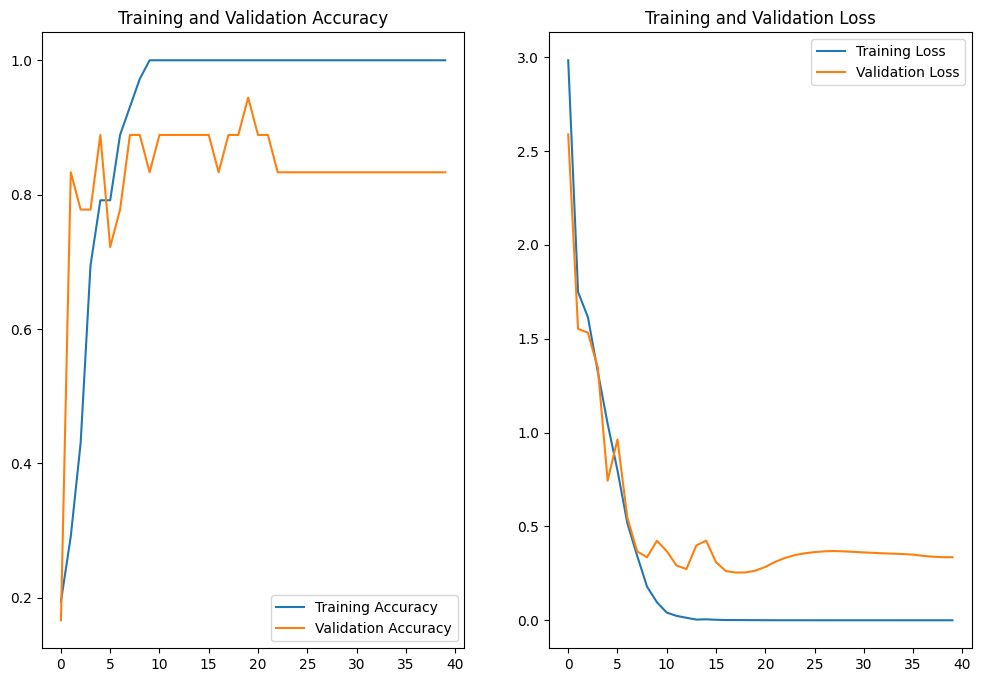

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt # Import for plotting training history

epochs = 250

# Define Callbacks
checkpoint_filepath = '/tmp/checkpoint.weights.h5' # Changed filepath to end with .weights.h5
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stopping_callback = EarlyStopping(
    monitor='val_accuracy',
    patience=20, # Number of epochs with no improvement after which training will be stopped.
    mode='max',
    restore_best_weights=True,
    verbose=1
)

print(f"Starting model training for {epochs} epochs...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[model_checkpoint_callback, early_stopping_callback]
)

print("Model training finished.")

# Visualize training history
# Get the training and validation accuracy and loss from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## 6. Evaluate the Model

After training, this section evaluates the model's performance on the unseen test dataset using `model.evaluate()`. This provides final metrics like test loss and test accuracy to assess how well the model generalizes to new data.

## 7. Load Model and Make Predictions

This section demonstrates how to load the previously saved model and use it to predict the class of a new, unseen image. A random image from the test dataset will be selected, preprocessed, and then passed to the model for prediction. The actual and predicted class labels will be displayed.

Model loaded successfully from: /tmp/fruit_classifier_model.h5
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Selected random image for prediction: /content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/test/cupuacu/download (2).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


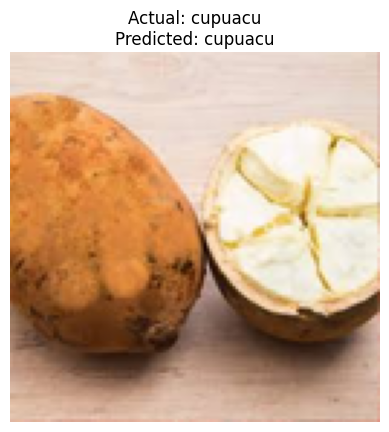

Actual Class: cupuacu
Predicted Class: cupuacu
Prediction Probabilities: [3.9142137e-03 9.7369099e-01 6.6829566e-04 1.1693782e-03 1.8321266e-02
 2.2356268e-03]


In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

# Load the saved model
loaded_model = tf.keras.models.load_model(saved_model_path)
print(f"Model loaded successfully from: {saved_model_path}")

# Get class names (assuming they are in the same order as when the model was trained)
# You can get this from train_ds.class_names or by listing subdirectories of train_dir
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print(f"Class names: {class_names}")

# --- Select a random image from the test set for prediction ---

# Get a list of all class subdirectories in the test directory
test_class_dirs = [os.path.join(test_dir, d) for d in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, d))]

if not test_class_dirs:
    print(f"No class subdirectories found in {test_dir}. Cannot pick a sample image.")
else:
    # Randomly choose one class directory
    random_class_path = random.choice(test_class_dirs)
    actual_class_name = os.path.basename(random_class_path)

    # Get all image files in that chosen class directory
    images_in_class = [f for f in os.listdir(random_class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

    if not images_in_class:
        print(f"No images found in class: {actual_class_name}. Cannot pick a sample image.")
    else:
        # Randomly choose one image from that class
        random_image_name = random.choice(images_in_class)
        random_image_path = os.path.join(random_class_path, random_image_name)

        print(f"Selected random image for prediction: {random_image_path}")

        # --- Preprocess the image ---
        img = Image.open(random_image_path).convert('RGB') # Ensure 3 channels
        img = img.resize((img_height, img_width))
        img_array = np.asarray(img) # Convert to numpy array
        img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
        img_array = rescale(img_array) # Apply the same normalization as training

        # --- Make prediction ---
        predictions = loaded_model.predict(img_array)
        predicted_class_index = np.argmax(predictions[0])
        predicted_class_name = class_names[predicted_class_index]

        # --- Display results ---
        plt.imshow(img) # Display the original PIL Image (not the normalized array)
        plt.title(f"Actual: {actual_class_name}\nPredicted: {predicted_class_name}")
        plt.axis('off')
        plt.show()

        print(f"Actual Class: {actual_class_name}")
        print(f"Predicted Class: {predicted_class_name}")
        print(f"Prediction Probabilities: {predictions[0]}")

In [16]:
print("Evaluating model on the test set...")
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Evaluating model on the test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.8000 - loss: 0.7239
Test Loss: 0.7239
Test Accuracy: 0.8000


## 6. Save the Trained Model

This section saves the entire trained Keras model to an .h5 file. This file will include the model's architecture, learned weights, and the configuration (optimizer, loss function, etc.) allowing it to be reloaded and used later without needing to rebuild the model from scratch.

In [17]:
import os

# Define the path to save the entire model
saved_model_path = '/tmp/fruit_classifier_model.h5'

# Save the entire model (architecture, weights, and optimizer state)
model.save(saved_model_path)

print(f"Model saved successfully to: {saved_model_path}")

# Optionally, load the best weights from the checkpoint into the model before saving
# This ensures the saved model reflects the best performance during training
# model.load_weights(checkpoint_filepath)
# model.save(saved_model_path.replace('.h5', '_best_weights.h5'))
# print(f"Model with best weights saved successfully to: {saved_model_path.replace('.h5', '_best_weights.h5')}")

Model saved successfully to: /tmp/fruit_classifier_model.h5


## 7. Classification Report

This section uses the trained model to make predictions on the entire test dataset and then generates a detailed classification report. The report will include metrics such as precision, recall, f1-score, and support for each class, providing a comprehensive evaluation of the model's performance beyond just overall accuracy.

In [19]:
from sklearn.metrics import classification_report
import numpy as np

# Get true labels from the test dataset
true_labels = []
for images, labels in test_ds:
    true_labels.extend(labels.numpy())

# Make predictions on the test dataset
predictions_probabilities = model.predict(test_ds)
predicted_labels = np.argmax(predictions_probabilities, axis=1)

# Get class names from the test_ds or as defined earlier
# Ensure class_names is sorted to match the order of labels from image_dataset_from_directory
class_names = sorted([d for d in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, d))])

# Generate and print the classification report
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step

Classification Report:
              precision    recall  f1-score   support

        acai       0.50      0.80      0.62         5
     cupuacu       0.80      0.80      0.80         5
    graviola       0.83      1.00      0.91         5
     guarana       1.00      0.80      0.89         5
     pupunha       1.00      1.00      1.00         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.80        30
   macro avg       0.86      0.80      0.80        30
weighted avg       0.86      0.80      0.80        30

